In [1]:
!pip install -q opencv-python-headless transformers torch tqdm pillow
!apt-get -qq install ffmpeg -y

In [2]:
import cv2
import numpy as np
import torch
from transformers import pipeline
from PIL import Image
from scipy.spatial import cKDTree
import glob
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("using", device)

using cpu


In [3]:
import os
try:
    from google.colab import files
    if not os.path.exists('sample.mp4'):
        print('Upload your indoor panoramic video:')
        uploaded = files.upload()
        video_path = list(uploaded.keys())[0]
    else:
        video_path = 'sample.mp4'
except ImportError:
    video_path = 'sample.mp4'
print('Using video path:', video_path)


Saving sample.mp4 to sample.mp4
sample.mp4


In [4]:
# pull frames out of the video, 2 fps is usually enough overlap for stitching
!rm -f frame_*.jpg
fps = 2
!ffmpeg -i "{video_path}" -vf fps={fps} -qscale:v 2 frame_%03d.jpg -hide_banner -loglevel error

frame_files = sorted(glob.glob("frame_*.jpg"))
print(len(frame_files), "frames extracted")

26 frames extracted


In [5]:
images = []
for f in tqdm(frame_files):
    img = cv2.imread(f)
    if img is not None:
        images.append(img)

print("stitching panorama, this can take a bit...")
stitcher = cv2.Stitcher_create()
status, stitched = stitcher.stitch(images)

if status != cv2.Stitcher_OK:
    print("stitching failed, frames probably don't overlap enough")

100%|██████████| 26/26 [00:00<00:00, 224.65it/s]


stitching panorama, this can take a bit...


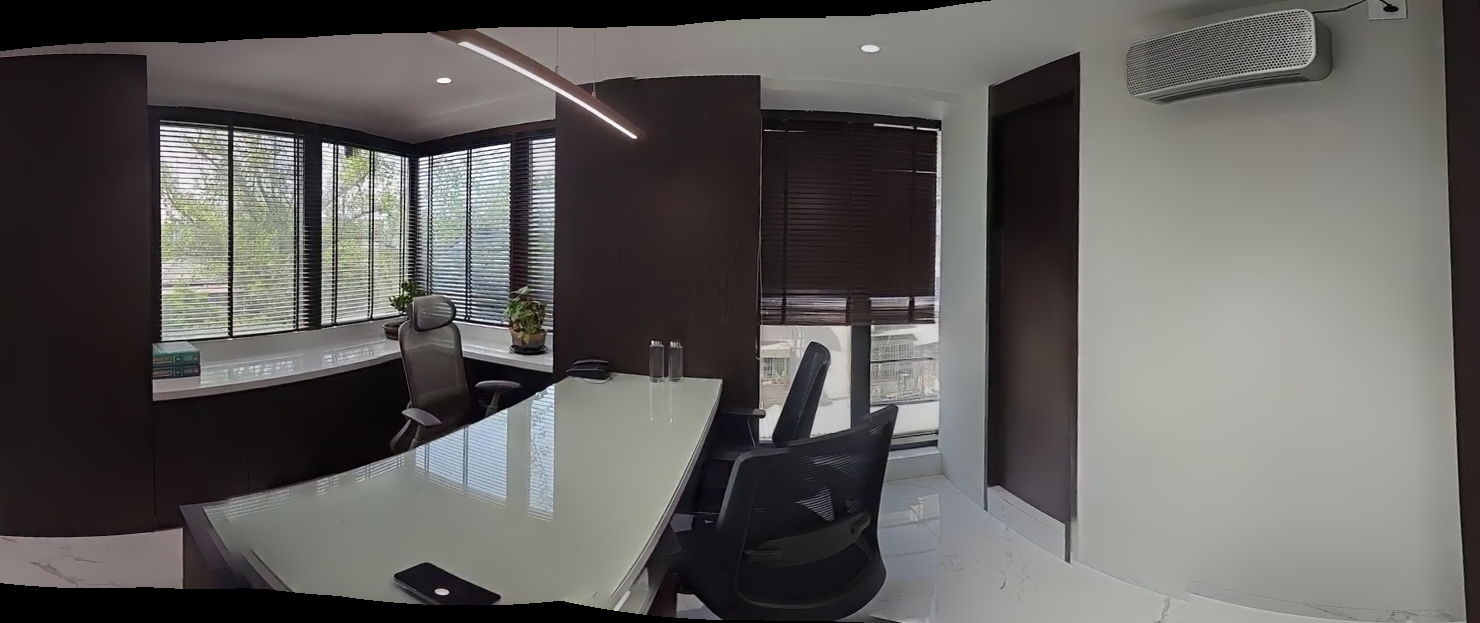

In [6]:
# crop out the black borders left after stitching
gray = cv2.cvtColor(stitched, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    pad_x, pad_y = int(w * 0.04), int(h * 0.04)
    stitched = stitched[y+pad_y : y+h-pad_y, x+pad_x : x+w-pad_x]

pano_img = Image.fromarray(cv2.cvtColor(stitched, cv2.COLOR_BGR2RGB))
width, height = pano_img.size
pano_img

In [7]:
!pip install -q --upgrade opencv-contrib-python-headless

# timm has to be this exact version or torch.hub explodes on ZoeDepth load
!pip install -q timm==0.6.7 einops plotly plyfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 11.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.0/510.0 kB 15.5 MB/s eta 0:00:00


In [8]:
print("Loading ZoeDepth (Indoor Metric Depth Model)... first run downloads weights (~1.4GB), can take a few minutes.")
zoe = torch.hub.load("isl-org/ZoeDepth", "ZoeD_N", pretrained=True, trust_repo=True).to(device).eval()
print("Model loaded.")

Loading ZoeDepth (Indoor Metric Depth Model)... first run downloads weights (~1.4GB), can take a few minutes.
Downloading: "https://github.com/isl-org/ZoeDepth/zipball/main" to /root/.cache/torch/hub/main.zip
img_size [384, 512]
The repository intel-isl_MiDaS does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip


/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Params passed to Resize transform:
	width:  512
	height:  384
	resize_target:  True
	keep_aspect_ratio:  True
	ensure_multiple_of:  32
	resize_method:  minimal
Using pretrained resource url::https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_N.pt
Downloading: "https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_N.pt" to /root/.cache/torch/hub/checkpoints/ZoeD_M12_N.pt


100%|██████████| 1.34G/1.34G [00:22<00:00, 64.6MB/s]


Loaded successfully
Model loaded.


In [9]:
print("Running Metric Depth Estimation (Meters)...")
width, height = pano_img.size

with torch.no_grad():
    depth_numpy = zoe.infer_pil(pano_img)

# smooth to flatten noise from stuff like window blinds / small reflective bits
depth_map = cv2.bilateralFilter(depth_numpy, d=9, sigmaColor=0.5, sigmaSpace=15)

STRIDE = 2  # raise to 3-4 for a lighter cloud, set to 1 for full resolution (slow)

u, v = np.meshgrid(np.arange(0, width, STRIDE), np.arange(0, height, STRIDE))
depth_sampled = depth_map[::STRIDE, ::STRIDE]
color_sampled = np.array(pano_img)[::STRIDE, ::STRIDE]

# the video pans roughly 120 degrees - adjust if your capture sweep was different
fov_x = 120.0 * (np.pi / 180.0)
fov_y = fov_x * (height / width)

theta = (u / width - 0.5) * fov_x
phi = (v / height - 0.5) * fov_y

# spherical -> cartesian using the actual metric depth values
X = depth_sampled * np.sin(theta) * np.cos(phi)
Y = -depth_sampled * np.sin(phi)
Z = depth_sampled * np.cos(theta) * np.cos(phi)

points = np.stack((X, Y, Z), axis=-1).reshape(-1, 3)
colors = (color_sampled / 255.0).reshape(-1, 3)
print(f"Point cloud: {len(points):,} points")

Running Metric Depth Estimation (Meters)...
Point cloud: 230,880 points


In [10]:
print("Removing statistical outliers...")
tree = cKDTree(points)
dists, _ = tree.query(points, k=31)  # k=31: includes the point itself at distance 0
mean_dists = dists[:, 1:].mean(axis=1)

global_mean = mean_dists.mean()
global_std = mean_dists.std()
threshold = global_mean + 1.5 * global_std  # std_ratio=1.5, matches the original script

keep_mask = mean_dists < threshold
points = points[keep_mask]
colors = colors[keep_mask]
print(f"Kept {keep_mask.sum():,} / {len(keep_mask):,} points")

Removing statistical outliers...
Kept 218,160 / 230,880 points


In [11]:
from plyfile import PlyData, PlyElement
ply_path = "room_zoedepth.ply"

vertex_colors = (colors * 255).astype(np.uint8)
vertex_data = np.zeros(len(points), dtype=[
    ('x', 'f4'), ('y', 'f4'), ('z', 'f4'),
    ('red', 'u1'), ('green', 'u1'), ('blue', 'u1')
])
vertex_data['x'], vertex_data['y'], vertex_data['z'] = points[:, 0], points[:, 1], points[:, 2]
vertex_data['red'], vertex_data['green'], vertex_data['blue'] = vertex_colors[:, 0], vertex_colors[:, 1], vertex_colors[:, 2]

el = PlyElement.describe(vertex_data, 'vertex')
PlyData([el], text=False).write(ply_path)
print(f"Successfully saved {ply_path}")

Successfully saved room_zoedepth.ply


In [12]:
import plotly.graph_objects as go

plot_points, plot_colors = points, colors
MAX_PLOT_POINTS = 40000  # full cloud lags plotly pretty hard, this is just for the preview
if len(plot_points) > MAX_PLOT_POINTS:
    idx = np.random.choice(len(plot_points), MAX_PLOT_POINTS, replace=False)
    plot_points = plot_points[idx]
    plot_colors = plot_colors[idx]

colors_str = [f"rgb({int(r*255)},{int(g*255)},{int(b*255)})" for r, g, b in plot_colors]

fig = go.Figure(data=[go.Scatter3d(
    x=plot_points[:, 0], y=plot_points[:, 1], z=plot_points[:, 2],
    mode="markers",
    marker=dict(size=1.5, color=colors_str)
)])
fig.update_layout(
    scene=dict(aspectmode="data"),
    margin=dict(l=0, r=0, b=0, t=0),
    height=700,
)
fig.show()

In [13]:
try:
    from google.colab import files
    files.download(ply_path)
except Exception:
    print(f'Point cloud successfully saved locally: {ply_path}')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>